# **Redes Neuronales Profundas Aplicadas en Clasificación de Helicobacter Pylori**

---

## Información del curso
* **Curso:** Redes neuronales 2019781
* **Profesor:** Luis Fernando Niño Vasquez
* **Semestre:** 2026-1

## Miembros del equipo

| Nombre | Correo |
| :--- | :--- |
| **David Felipe Marin Rosas** | dmarinro@unal.edu.co |
| **Laura Camila Girón Pinto** | lgironp@unal.edu.co |
| **Nicolas Martinez Lopez** | nmartinezl@unal.edu.co |
| **Diego Esteban Morales Granados** |dimorales@unal.edu.co|
| **Sergio Ivan Motta Doncel** | smottad@unal.edu.co |


# **Importar Librerías**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

# **Importar Dataset Aumentado**

In [ ]:
url = "https://raw.githubusercontent.com/nmart1nezl/NeuronalNetworks-Group6/refs/heads/main/project/data/microbioma_aumentado_gan_CLR.csv"
df = pd.read_csv(url)
df.head()

,Actinobacillus,Actinomyces,Aggregatibacter,Alkalibacterium,Atopobium,Bacillus,Bacteroides,Bulleidia,Campylobacter,Capnocytophaga,...,Stenotrophomonas,Streptococcus,TG5,Tannerella,Thiobacillus,Treponema,Unclassified,Veillonella,[Prevotella],Helicobacter_Pylori
0,1.538448,2.611121,0.090600,2.934264,1.407379,0.302863,2.998858,0.994235,0.230783,-0.166279,...,1.319868,5.005439,-0.575660,1.972183,-0.097108,-0.577025,4.772107,4.545053,2.956943,1
1,-0.795223,5.041967,-0.277469,2.055500,4.088863,-0.832409,3.427864,3.404945,2.412920,0.766392,...,1.844798,5.166961,-0.911502,0.923075,-0.259456,0.314328,4.127694,5.234553,4.944114,1
2,-0.753201,4.169159,-0.618868,1.766772,3.808294,-0.837662,2.180248,2.204665,1.092995,3.220162,...,1.254338,5.010882,-0.337349,3.329791,0.781586,5.077777,4.749383,4.852282,2.955911,1
3,-0.342697,5.641208,-0.431330,2.198931,3.621230,-0.625385,2.532394,3.680268,1.956328,3.734659,...,1.918132,6.260952,-0.096927,3.013489,0.753137,4.742264,5.360091,5.109146,3.207649,1
4,0.639833,1.527454,-0.588071,3.393167,-0.574304,-0.115027,3.806814,0.812103,-0.369316,-0.624999,...,3.210948,6.091112,-0.039431,-0.993272,-0.718688,-0.749593,5.424560,2.700714,1.141545,1


In [ ]:
df.shape

(2000, 61)

# **Importar Dataset Original**

In [ ]:
url_otu_genus = "https://raw.githubusercontent.com/nmart1nezl/NeuronalNetworks-Group6/refs/heads/main/project/data/otu_genus_clr_prevfiltered-hp.csv"
otu_genus = pd.read_csv(url_otu_genus)
otu_genus.head()

,Sample_ID,Actinobacillus,Actinomyces,Aggregatibacter,Alkalibacterium,Atopobium,Bacillus,Bacteroides,Bulleidia,Campylobacter,...,Staphylococcus,Stenotrophomonas,Streptococcus,TG5,Tannerella,Thiobacillus,Treponema,Unclassified,Veillonella,[Prevotella]
0,P001Z12,1.136165,5.666962,-1.329606,5.125296,3.407573,2.507664,5.543468,3.427601,-1.329606,...,2.675229,3.262707,7.029766,-1.329606,-1.329606,2.243472,-1.329606,6.580870,6.379528,5.467354
1,P001Z13,-0.348473,6.435700,0.393300,2.158804,3.982938,-1.146599,2.089231,4.501488,3.738455,...,0.896899,0.814463,7.661200,-0.348473,3.209424,-0.105595,2.686182,6.275081,6.072512,4.416165
2,P001Z14,1.367808,5.945386,0.072880,3.663450,3.124310,-1.512935,4.293321,3.337950,3.367871,...,-1.512935,2.748320,7.190134,-1.512935,2.652594,-1.512935,1.913662,5.645632,6.106997,5.556124
3,P001Z18,4.143998,5.634243,2.947621,3.197061,2.785120,-0.737450,3.665411,2.930816,2.287356,...,-1.140968,2.203289,7.952309,-1.140968,2.626075,-1.140968,1.656895,6.257157,6.162395,4.278155
4,P002Z18,2.350095,3.820098,-1.238502,6.664077,-1.238502,2.943589,6.037687,-1.238502,-1.238502,...,3.483684,5.517361,6.830796,-1.238502,-1.238502,-1.238502,-1.238502,7.214300,3.880349,-1.238502


In [ ]:
url_labels = "https://raw.githubusercontent.com/nmart1nezl/NeuronalNetworks-Group6/refs/heads/main/project/data/sample_metadata_binary-hp.csv"
labels = pd.read_csv(url_labels)
labels.head()

,Sample_ID,Hp_Status_binary,label_binary,Hp_CagA_Status,Score
0,P001Z12,H.p.-,0,H.p.-,not aplicable
1,P001Z13,H.p.-,0,H.p.-,not aplicable
2,P001Z14,H.p.-,0,H.p.-,not aplicable
3,P001Z18,H.p.-,0,H.p.-,not aplicable
4,P002Z18,H.p.-,0,H.p.-,not aplicable


In [ ]:
df_original = otu_genus.merge(labels[['Sample_ID', 'label_binary']], on='Sample_ID', how='inner')
# Drop Sample_ID from df_original as requested, it's not needed for the model features
df_original = df_original.drop(columns=['Sample_ID'])

print("Shape of df_original:", df_original.shape)
df_original.head()

Shape of df_original: (29, 61)


,Actinobacillus,Actinomyces,Aggregatibacter,Alkalibacterium,Atopobium,Bacillus,Bacteroides,Bulleidia,Campylobacter,Capnocytophaga,...,Stenotrophomonas,Streptococcus,TG5,Tannerella,Thiobacillus,Treponema,Unclassified,Veillonella,[Prevotella],label_binary
0,1.136165,5.666962,-1.329606,5.125296,3.407573,2.507664,5.543468,3.427601,-1.329606,-1.329606,...,3.262707,7.029766,-1.329606,-1.329606,2.243472,-1.329606,6.580870,6.379528,5.467354,0
1,-0.348473,6.435700,0.393300,2.158804,3.982938,-1.146599,2.089231,4.501488,3.738455,4.682144,...,0.814463,7.661200,-0.348473,3.209424,-0.105595,2.686182,6.275081,6.072512,4.416165,0
2,1.367808,5.945386,0.072880,3.663450,3.124310,-1.512935,4.293321,3.337950,3.367871,3.452609,...,2.748320,7.190134,-1.512935,2.652594,-1.512935,1.913662,5.645632,6.106997,5.556124,0
3,4.143998,5.634243,2.947621,3.197061,2.785120,-0.737450,3.665411,2.930816,2.287356,2.930816,...,2.203289,7.952309,-1.140968,2.626075,-1.140968,1.656895,6.257157,6.162395,4.278155,0
4,2.350095,3.820098,-1.238502,6.664077,-1.238502,2.943589,6.037687,-1.238502,-1.238502,-1.238502,...,5.517361,6.830796,-1.238502,-1.238502,-1.238502,-1.238502,7.214300,3.880349,-1.238502,0


# **Divide Dataset in Test, Validation and Training**

In [ ]:
# Define features (X) and target (y)
X = df.drop('Helicobacter_Pylori', axis=1)
y = df['Helicobacter_Pylori']

# First split: Separate 70% for the test set and 30% for (train + validation)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.7, stratify=y, random_state=42
)

# Second split: From the remaining 30% (X_temp, y_temp),
# split it equally (50%/50%) to get 15% for validation and 15% for training.
# 0.5 of X_temp (30%) is 15% of the original dataset.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Display the shapes of the resulting datasets
print(f"Original dataset shape: {df.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Verify percentages (approximately)
total_rows = df.shape[0]
print(f"Train percentage: {len(X_train) / total_rows:.2%}")
print(f"Validation percentage: {len(X_val) / total_rows:.2%}")
print(f"Test percentage: {len(X_test) / total_rows:.2%}")

Original dataset shape: (2000, 61)
X_train shape: (300, 60)
y_train shape: (300,)
X_val shape: (300, 60)
y_val shape: (300,)
X_test shape: (1400, 60)
y_test shape: (1400,)
Train percentage: 15.00%
Validation percentage: 15.00%
Test percentage: 70.00%


In [ ]:
X_original = df_original.drop('label_binary', axis=1)
y_original = df_original['label_binary']

print(f"Original dataset shape: {df_original.shape}")
print(f"X_original shape: {X_original.shape}")
print(f"y_original shape: {y_original.shape}")

Original dataset shape: (29, 61)
X_original shape: (29, 60)
y_original shape: (29,)


# **Entrenamiento y Test de Redes Neuronales Profundas**

En esta sección se presenta el entrenamiento y evaluación de tres arquitecturas de redes
neuronales profundas para la clasificación binaria de *Helicobacter pylori* a partir de
perfiles de abundancia microbiana transformados con CLR.

1. **MLP con Regularización Fuerte**  
   Arquitectura base compuesta por múltiples capas densas (*fully connected*) apiladas en
   secuencia — lo que la califica como red profunda — con activaciones ReLU, Normalización
   por Lotes y Dropout progresivo. Esta profundidad permite aprender representaciones
   jerárquicas de las co-abundancias microbianas, donde las capas iniciales capturan
   patrones locales entre géneros y las capas superiores abstracciones de mayor orden.
   La regularización combinada contrarresta el sobreajuste inherente a datasets de tamaño
   moderado como el empleado en este estudio.

2. **MLP Residual (ResNet Tabular)**  
   Variante del MLP que incorpora conexiones residuales (*skip connections*) entre bloques,
   inspiradas en ResNet. Su carácter profundo no solo proviene del número de capas, sino
   de que las skip connections hacen viable ese apilamiento: al permitir que los gradientes
   fluyan directamente a través de la red sin degradarse, evitan el problema del
   desvanecimiento del gradiente que limita a los MLP convencionales cuando se profundizan.
   En el contexto del microbioma, esto permite que la red capture simultáneamente relaciones
   lineales directas entre géneros e interacciones no lineales de orden superior.

3. **TabNet**  
   Arquitectura diseñada específicamente para datos tabulares cuya profundidad se articula
   de forma distinta a las anteriores: en lugar de apilar capas densas, encadena múltiples
   pasos secuenciales (*n_steps*), donde cada paso aplica un mecanismo de atención para
   seleccionar las features más informativas y un transformador para procesarlas, antes de
   ceder el control al siguiente paso. Este procesamiento multi-etapa constituye su
   profundidad y, como efecto secundario valioso, produce máscaras de atención
   interpretables que revelan qué géneros bacterianos contribuyen más a la predicción —
   una propiedad especialmente útil en estudios de microbioma clínico.

In [ ]:
NUM_EPOCHS = 20
MODEL_METRICS = ['accuracy']

## MLP con Regularización Fuerte

In [ ]:
def build_mlp_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.4),
        layers.Dense(128),        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.3),
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.3),
        layers.Dense(32),
        layers.ReLU(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Get input shape from the training data
input_shape = X_train.shape[1]

# Build the MLP model
mlp_model = build_mlp_model(input_shape)

# Compile the model
mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=MODEL_METRICS
)

mlp_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_53 (Dense)                │ (None, 256)            │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_26 (ReLU)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_27 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_28 (ReLU)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_29 (ReLU)                 │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,673 (237.00 KB)

 Trainable params: 59,777 (233.50 KB)

 Non-trainable params: 896 (3.50 KB)

### **Entrenamiento del Modelo MLP**

Procedemos a entrenar el modelo MLP utilizando el conjunto de entrenamiento y monitoreando su rendimiento en el conjunto de validación.

In [ ]:
history_mlp = mlp_model.fit(
    X_train,
    y_train,
    epochs=NUM_EPOCHS,  # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.6400 - loss: 0.6226 - val_accuracy: 0.7300 - val_loss: 0.5633
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9200 - loss: 0.3300 - val_accuracy: 0.9900 - val_loss: 0.3016
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9700 - loss: 0.2230 - val_accuracy: 0.9933 - val_loss: 0.1625
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9833 - loss: 0.1412 - val_accuracy: 1.0000 - val_loss: 0.0875
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9933 - loss: 0.0850 - val_accuracy: 1.0000 - val_loss: 0.0447
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0500 - val_accuracy: 1.0000 - val_loss: 0.0259
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9967 - loss: 0.0413 - val_accuracy: 1.0000 - val_loss: 0.0170
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0271 - val_accuracy: 1.0000 - v

### **Evaluación del Modelo MLP en el conjunto de Test**

Una vez entrenado el modelo, evaluamos su rendimiento en el conjunto de test para obtener una métrica imparcial de su capacidad de generalización.

In [ ]:
loss_mlp_orig_from_test_cell, accuracy_mlp_orig_from_test_cell = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"MLP Original (from Test cell) Loss: {loss_mlp_orig_from_test_cell:.4f}")
print(f"MLP Original (from Test cell) Accuracy: {accuracy_mlp_orig_from_test_cell:.4f}")

MLP Original (from Test cell) Loss: 0.0011
MLP Original (from Test cell) Accuracy: 1.0000


### **Desempeño Validación**

Evaluamos el modelo en el conjunto de validación. Aunque ya se utilizó durante el entrenamiento para el monitoreo, es útil ver las métricas finales.

In [ ]:
loss_val, accuracy_val = mlp_model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {loss_val:.4f}")
print(f"Validation Accuracy: {accuracy_val:.4f}")

Validation Loss: 0.0012
Validation Accuracy: 1.0000


### **Desempeño Conjunto Original**

Evaluamos el modelo en el conjunto de datos original (es decir, con datos reales y no datos sintéticos) para verificar si hay un sobreajuste evidente (overfitting).

In [ ]:
loss_mlp_orig_from_train_cell, accuracy_mlp_orig_from_train_cell = mlp_model.evaluate(X_original, y_original, verbose=0)
print(f"MLP Original (from Train cell) Loss: {loss_mlp_orig_from_train_cell:.4f}")
print(f"MLP Original (from Train cell) Accuracy: {accuracy_mlp_orig_from_train_cell:.4f}")

MLP Original (from Train cell) Loss: 0.3284
MLP Original (from Train cell) Accuracy: 0.8966


### **Rendimiento**

A continuación, se muestran los gráficos de la pérdida y la precisión del modelo MLP durante el entrenamiento y la validación. Esto nos permite observar la evolución del modelo y detectar posibles signos de sobreajuste o falta de ajuste.

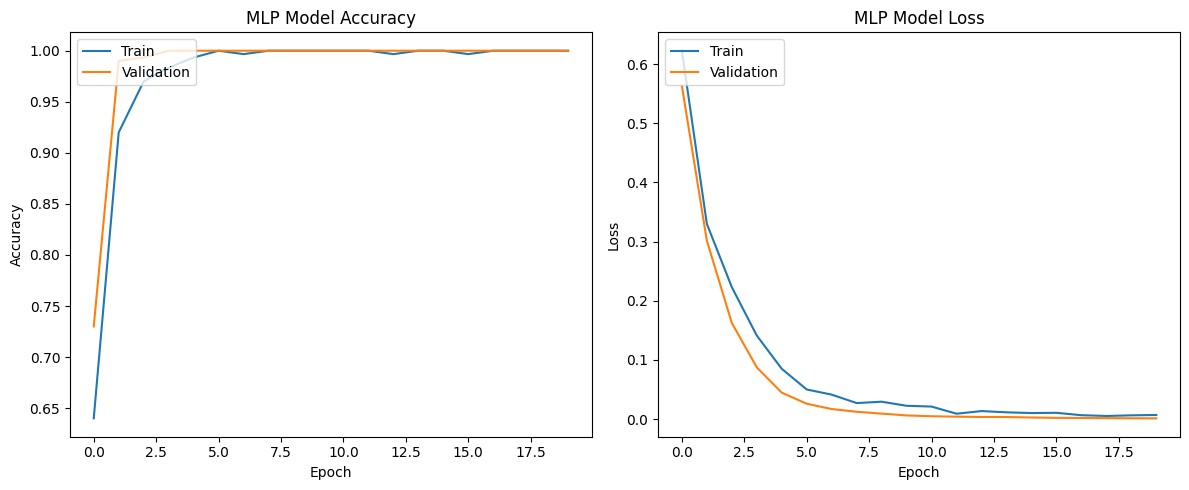

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['accuracy'])
plt.plot(history_mlp.history['val_accuracy'])
plt.title('MLP Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['loss'])
plt.plot(history_mlp.history['val_loss'])
plt.title('MLP Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

## MLP Residual (ResNet Tabular)

Implementaremos una red MLP con conexiones residuales, inspirada en la arquitectura ResNet, pero adaptada para datos tabulares. Esto permite entrenar redes más profundas mitigando el problema del desvanecimiento del gradiente y mejorando el flujo de información a través de la red.

In [ ]:
def residual_block(x, units, dropout_rate):
    # Save the input for the residual connection
    shortcut = x

    # First Dense layer + BN + ReLU
    x = layers.Dense(units)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)

    # Second Dense layer + BN
    x = layers.Dense(units)(x)
    x = layers.BatchNormalization()(x)

    # Add the shortcut connection (ensure dimensions match)
    # If the number of units changed, we need a projection for the shortcut
    if shortcut.shape[-1] != units:
        shortcut = layers.Dense(units)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.add([x, shortcut]) # Add shortcut to the output of the second layer
    x = layers.ReLU()(x) # Apply ReLU after adding the shortcut
    return x

def build_resnet_tabular_model(input_shape):
    inputs = keras.Input(shape=(input_shape,))

    # Initial layer
    x = layers.Dense(256)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.4)(x)

    # Residual blocks
    x = residual_block(x, 256, 0.3) # Residual block maintains 256 units
    x = residual_block(x, 128, 0.3) # Residual block changes to 128 units
    x = residual_block(x, 64, 0.2)  # Residual block changes to 64 units

    # Final output layer
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# Get input shape from the training data
input_shape = X_train.shape[1]

# Build the ResNet Tabular model
resnet_tabular_model = build_resnet_tabular_model(input_shape)

# Compile the model
resnet_tabular_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=MODEL_METRICS
)

resnet_tabular_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_58 (Dense)    │ (None, 256)       │     15,616 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_58[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_30 (ReLU)     │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 256)       │          0 │ re_lu_30[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_59 (Dense)    │ (None, 256)       │     65,792 │ dropout_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_59[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_31 (ReLU)     │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 256)       │          0 │ re_lu_31[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_60 (Dense)    │ (None, 256)       │     65,792 │ dropout_33[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_60[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ dropout_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_32 (ReLU)     │ (None, 256)       │          0 │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_61 (Dense)    │ (None, 128)       │     32,896 │ re_lu_32[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_61[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_33 (ReLU)     │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 128)       │          0 │ re_lu_33[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_62 (Dense)    │ (None, 128)       │     16,512 │ dropout_34[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_63 (Dense)    │ (None, 128)       │     32,896 │ re_lu_32[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_62[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 255,617 (998.50 KB)

 Trainable params: 252,929 (988.00 KB)

 Non-trainable params: 2,688 (10.50 KB)

### **Entrenamiento del Modelo MLP Residual**

Entrenaremos el modelo MLP Residual con los mismos conjuntos de datos de entrenamiento y validación, y observaremos cómo se comporta en comparación con el MLP simple.

In [ ]:
history_resnet = resnet_tabular_model.fit(
    X_train,
    y_train,
    epochs=NUM_EPOCHS,  # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.7667 - loss: 0.4552 - val_accuracy: 0.5600 - val_loss: 0.5791
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9567 - loss: 0.1396 - val_accuracy: 0.7467 - val_loss: 0.4096
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9933 - loss: 0.0499 - val_accuracy: 0.9500 - val_loss: 0.1393
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0247 - val_accuracy: 0.9833 - val_loss: 0.0629
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0202 - val_accuracy: 0.9933 - val_loss: 0.0336
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0171 - val_accuracy: 1.0000 - val_loss: 0.0182
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0122 - val_accuracy: 1.0000 - val_loss: 0.0128
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0117 - val_accuracy: 1.0000 - v

### **Desempeño Test**

In [ ]:
loss_resnet_orig_from_test_cell, accuracy_resnet_orig_from_test_cell = resnet_tabular_model.evaluate(X_test, y_test, verbose=0)
print(f"ResNet Original (from Test cell) Loss: {loss_resnet_orig_from_test_cell:.4f}")
print(f"ResNet Original (from Test cell) Accuracy: {accuracy_resnet_orig_from_test_cell:.4f}")

ResNet Original (from Test cell) Loss: 0.0003
ResNet Original (from Test cell) Accuracy: 1.0000


### **Desempeño Validación**

In [ ]:
loss_resnet_val, accuracy_resnet_val = resnet_tabular_model.evaluate(X_val, y_val, verbose=0)
print(f"ResNet Tabular Validation Loss: {loss_resnet_val:.4f}")
print(f"ResNet Tabular Validation Accuracy: {accuracy_resnet_val:.4f}")

ResNet Tabular Validation Loss: 0.0003
ResNet Tabular Validation Accuracy: 1.0000


### **Desempeño con el Conjunto Original**

In [ ]:
loss_resnet_orig_from_train_cell, accuracy_resnet_orig_from_train_cell = resnet_tabular_model.evaluate(X_original, y_original, verbose=0)
print(f"ResNet Original (from Train cell) Loss: {loss_resnet_orig_from_train_cell:.4f}")
print(f"ResNet Original (from Train cell) Accuracy: {accuracy_resnet_orig_from_train_cell:.4f}")

ResNet Original (from Train cell) Loss: 0.4666
ResNet Original (from Train cell) Accuracy: 0.9310


### **Rendimiento**

A continuación, se muestran los gráficos de la pérdida y la precisión del modelo MLP Residual durante el entrenamiento y la validación. Esto nos permite observar la evolución del modelo y detectar posibles signos de sobreajuste o falta de ajuste.

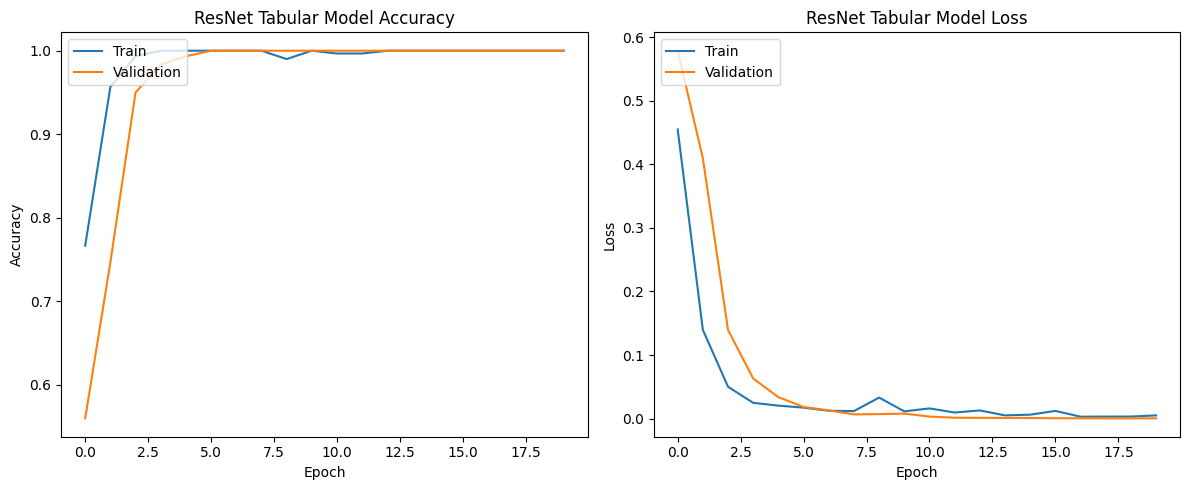

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])
plt.title('ResNet Tabular Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'])
plt.plot(history_resnet.history['val_loss'])
plt.title('ResNet Tabular Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

## TabNet

TabNet es una arquitectura de red neuronal profunda diseñada para datos tabulares, que combina las ventajas del aprendizaje profundo con la interpretabilidad y la eficiencia de los modelos basados en árboles. Utiliza un mecanismo de atención secuencial para seleccionar las características más relevantes en cada paso, permitiendo una mejor comprensión de las decisiones del modelo.

In [ ]:
class FeatureTransformer(layers.Layer):
    def __init__(self, units, dropout_rate, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.dense = layers.Dense(units, activation='relu')
        self.bn = layers.BatchNormalization()
        self.dropout = layers.Dropout(dropout_rate)

    def call(self, x):
        x = self.dense(x)
        x = self.bn(x)
        return self.dropout(x)

class AttentiveTransformer(layers.Layer):
    def __init__(self, units, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.dense = layers.Dense(units, activation='relu') # 'units' here refers to output units
        self.bn = layers.BatchNormalization()

    def call(self, x):
        x = self.dense(x)
        x = self.bn(x)
        return tf.nn.softmax(x)

class TabNet(keras.Model):
    def __init__(self, feature_columns, num_classes=1, N_a=8, N_d=8, n_steps=3, gamma=1.3, dropout_rate=0.2, **kwargs):
        super().__init__(**kwargs)
        self.feature_columns = feature_columns
        self.num_classes = num_classes
        self.N_a = N_a # Attentive transformer output size (for attention features)
        self.N_d = N_d # Feature transformer output size (for main features)
        self.n_steps = n_steps # Number of sequential attention steps
        self.gamma = gamma # Relaxation factor for attention mask
        self.dropout_rate = dropout_rate # Corrected typo `self_dropout_rate`

        self.input_dim = len(feature_columns)

        # Feature transformer for the first step's attention input (processes raw inputs)
        # Takes `input_dim` features and outputs `N_d + N_a`
        self.initial_feature_transformer = FeatureTransformer(self.N_d + self.N_a, self.dropout_rate, name="initial_ft")

        # Attentive transformers (one for each step)
        # These take `N_a` features (from decision_ft or initial_ft) and output `input_dim` features (for the mask)
        self.attentive_transformers = [AttentiveTransformer(self.input_dim, name=f"at_{i}") for i in range(self.n_steps)]

        # Decision feature transformers (one for each subsequent step's attention input)
        # These process the previous step's aggregated output (M_b_out of size N_d) to generate input for the attentive transformer.
        # They should output N_d + N_a units.
        self.decision_feature_transformers = [
            FeatureTransformer(self.N_d + self.N_a, self.dropout_rate, name=f"decision_ft_{i}")
            for i in range(self.n_steps - 1) # N-1 for subsequent steps (first step uses initial_feature_transformer)
        ]

        # Main feature transformers (one for each step)
        # These process the original inputs * M_i (input_dim features) and output N_d + N_a
        self.main_feature_transformers = [
            FeatureTransformer(self.N_d + self.N_a, self.dropout_rate, name=f"main_ft_{i}")
            for i in range(self.n_steps)
        ]

        self.output_layers = []
        if self.num_classes == 1:
            self.output_layers.append(layers.Dense(1, activation='sigmoid', name='output_sigmoid'))
        else:
            self.output_layers.append(layers.Dense(self.num_classes, activation='softmax', name='output_softmax'))

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        prior_scales = tf.ones((batch_size, self.input_dim))
        M_b_out = tf.zeros((batch_size, self.N_d)) # Aggregated feature transformer outputs

        for i in range(self.n_steps):
            # Step 1: Generate input for the attentive transformer
            if i == 0:
                # For the first step, use the initial_feature_transformer on the raw inputs
                x_for_attention = self.initial_feature_transformer(inputs)
            else:
                # For subsequent steps, use a decision_feature_transformer on the aggregated output M_b_out
                x_for_attention = self.decision_feature_transformers[i-1](M_b_out)

            # Step 2: Pass through attentive transformer to get the attention weights (mask input)
            # The attentive transformer takes the 'N_a' part of x_for_attention and outputs 'input_dim' features for the mask
            att_output = self.attentive_transformers[i](x_for_attention[:, self.N_d:]) # Take the `N_a` part of the output for attention

            # Step 3: Create the attention mask
            M_i = prior_scales * att_output # Attention mask (input_dim units)

            # Step 4: Apply mask to original features and pass through main feature transformer
            transformed_features = self.main_feature_transformers[i](inputs * M_i) # Takes input_dim features, outputs N_d + N_a

            # Step 5: Split transformed features into d_out and a_out
            d_out = tf.nn.relu(transformed_features[:, :self.N_d])
            a_out = tf.nn.relu(transformed_features[:, self.N_d:]) # a_out is not explicitly used here, but kept for completeness

            # Step 6: Update prior scales and aggregated output M_b_out
            prior_scales = prior_scales * (self.gamma - M_i) # Update for next step
            M_b_out = M_b_out + d_out # Aggregate d_out

        # Final output layer uses the last aggregated output M_b_out
        final_output = self.output_layers[0](M_b_out)
        return final_output

# Get feature columns (all columns except the target) and input shape
feature_columns = X_train.columns.tolist()
input_shape = X_train.shape[1]

# Build the TabNet model
tabnet_model = TabNet(feature_columns=feature_columns, num_classes=1, N_a=8, N_d=8, n_steps=3, dropout_rate=0.2)

# Compile the model
tabnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=MODEL_METRICS
)

# Build the model by passing an input shape to the call method to create weights
tabnet_model.build(input_shape=(None, input_shape))
tabnet_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'tab_net_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "tab_net_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ initial_ft (FeatureTransformer) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ at_0 (AttentiveTransformer)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ at_1 (AttentiveTransformer)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ at_2 (AttentiveTransformer)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decision_ft_0                   │ ?                      │   0 (unbuilt) │
│ (FeatureTransformer)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decision_ft_1                   │ ?                      │   0 (unbuilt) │
│ (FeatureTransformer)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ main_ft_0 (FeatureTransformer)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ main_ft_1 (FeatureTransformer)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ main_ft_2 (FeatureTransformer)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_sigmoid (Dense)          │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### **Entrenamiento del Modelo TabNet**

Ahora entrenaremos el modelo TabNet utilizando los conjuntos de entrenamiento y validación. Observaremos su rendimiento en comparación con las arquitecturas MLP anteriores, prestando especial atención a cómo maneja los datos tabulares y si puede ofrecer una mejor generalización o insights sobre las características.

In [ ]:
history_tabnet = tabnet_model.fit(
    X_train,
    y_train,
    epochs=NUM_EPOCHS,  # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.5000 - loss: 0.6759 - val_accuracy: 0.5000 - val_loss: 0.6451
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5000 - loss: 0.6416 - val_accuracy: 0.5267 - val_loss: 0.6088
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5667 - loss: 0.6053 - val_accuracy: 0.6433 - val_loss: 0.5655
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6700 - loss: 0.5602 - val_accuracy: 0.7667 - val_loss: 0.5110
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7700 - loss: 0.5089 - val_accuracy: 0.8900 - val_loss: 0.4668
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9100 - loss: 0.4630 - val_accuracy: 0.9633 - val_loss: 0.4341
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9367 - loss: 0.4209 - val_accuracy: 0.9633 - val_loss: 0.3867
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9500 - loss: 0.3759 - val_accuracy: 0.9900 - v

### **Desmpeño Test**

In [ ]:
loss_tabnet_orig_from_test_cell, accuracy_tabnet_orig_from_test_cell = tabnet_model.evaluate(X_test, y_test, verbose=0)
print(f"TabNet Original (from Test cell) Loss: {loss_tabnet_orig_from_test_cell:.4f}")
print(f"TabNet Original (from Test cell) Accuracy: {accuracy_tabnet_orig_from_test_cell:.4f}")

TabNet Original (from Test cell) Loss: 0.0306
TabNet Original (from Test cell) Accuracy: 1.0000


### **Desempeño Validación**

In [ ]:
loss_tabnet_val, accuracy_tabnet_val = tabnet_model.evaluate(X_val, y_val, verbose=0)
print(f"TabNet Validation Loss: {loss_tabnet_val:.4f}")
print(f"TabNet Validation Accuracy: {accuracy_tabnet_val:.4f}")

TabNet Validation Loss: 0.0323
TabNet Validation Accuracy: 1.0000


### **Desempeño con el Conjunto Original**

In [ ]:
loss_tabnet_orig_from_train_cell, accuracy_tabnet_orig_from_train_cell = tabnet_model.evaluate(X_original, y_original, verbose=0)
print(f"TabNet Original (from Train cell) Loss: {loss_tabnet_orig_from_train_cell:.4f}")
print(f"TabNet Original (from Train cell) Accuracy: {accuracy_tabnet_orig_from_train_cell:.4f}")

TabNet Original (from Train cell) Loss: 0.5687
TabNet Original (from Train cell) Accuracy: 0.8276


### **Rendimiento**

A continuación, se muestran los gráficos de la pérdida y la precisión del modelo TabNet durante el entrenamiento y la validación. Esto nos permite observar la evolución del modelo y detectar posibles signos de sobreajuste o falta de ajuste.

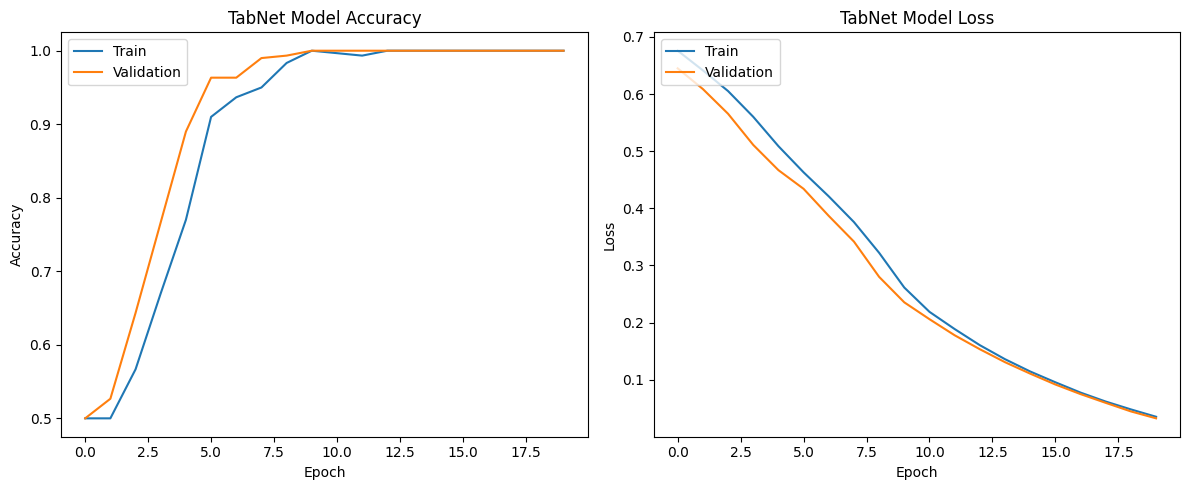

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_tabnet.history['accuracy'])
plt.plot(history_tabnet.history['val_accuracy'])
plt.title('TabNet Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_tabnet.history['loss'])
plt.plot(history_tabnet.history['val_loss'])
plt.title('TabNet Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

## Comparación Modelos



Las celdas de código a continuación tienen como objetivo proporcionar una evaluación detallada de estos tres modelos utilizando el conjunto de datos `X_original` y `y_original`. Para cada modelo, se generarán y mostrarán las siguientes métricas:

*   **Matriz de Confusión:** Una tabla que resume el rendimiento de un algoritmo de clasificación en un conjunto de datos de prueba. Muestra el número de predicciones correctas e incorrectas, desglosadas por cada clase.
*   **Reporte de Clasificación:** Un informe textual que incluye métricas clave como la `precisión` (precision), `exhaustividad` (recall), `puntuación F1` (f1-score) y el `soporte` (support) para cada clase, así como promedios (macro y ponderado) para el rendimiento general del modelo. Estas métricas son cruciales para entender el desempeño de los modelos, especialmente en escenarios de clasificación binaria como este, donde se busca identificar la presencia o ausencia de *Helicobacter Pylori*.

In [ ]:
# --- MLP Model --- #
print("\n--- MLP Model Evaluation (using X_original, y_original) ---")
# Make predictions on the original dataset
y_pred_mlp = mlp_model.predict(X_original)
# Convert probabilities to binary predictions (0 or 1)
y_pred_mlp_binary = (y_pred_mlp > 0.5).astype(int)

# Confusion Matrix
cm_mlp = confusion_matrix(y_original, y_pred_mlp_binary)
print("Confusion Matrix (MLP - Original):\n", cm_mlp)

# Classification Report
report_mlp = classification_report(y_original, y_pred_mlp_binary, target_names=['Class 0', 'Class 1'])
print("Classification Report (MLP - Original):\n", report_mlp)

# --- ResNet Tabular Model --- #
print("\n--- ResNet Tabular Model Evaluation (using X_original, y_original) ---")
# Make predictions on the original dataset
y_pred_resnet = resnet_tabular_model.predict(X_original)
# Convert probabilities to binary predictions (0 or 1)
y_pred_resnet_binary = (y_pred_resnet > 0.5).astype(int)

# Confusion Matrix
cm_resnet = confusion_matrix(y_original, y_pred_resnet_binary)
print("Confusion Matrix (ResNet Tabular - Original):\n", cm_resnet)

# Classification Report
report_resnet = classification_report(y_original, y_pred_resnet_binary, target_names=['Class 0', 'Class 1'])
print("Classification Report (ResNet Tabular - Original):\n", report_resnet)

# --- TabNet Model --- #
print("\n--- TabNet Model Evaluation (using X_original, y_original) ---")
# Make predictions on the original dataset
y_pred_tabnet = tabnet_model.predict(X_original)
# Convert probabilities to binary predictions (0 or 1)
y_pred_tabnet_binary = (y_pred_tabnet > 0.5).astype(int)

# Confusion Matrix
cm_tabnet = confusion_matrix(y_original, y_pred_tabnet_binary)
print("Confusion Matrix (TabNet - Original):\n", cm_tabnet)

# Classification Report
report_tabnet = classification_report(y_original, y_pred_tabnet_binary, target_names=['Class 0', 'Class 1'])
print("Classification Report (TabNet - Original):\n", report_tabnet)


--- MLP Model Evaluation (using X_original, y_original) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Confusion Matrix (MLP - Original):
 [[ 6  3]
 [ 0 20]]
Classification Report (MLP - Original):
               precision    recall  f1-score   support

     Class 0       1.00      0.67      0.80         9
     Class 1       0.87      1.00      0.93        20

    accuracy                           0.90        29
   macro avg       0.93      0.83      0.87        29
weighted avg       0.91      0.90      0.89        29


--- ResNet Tabular Model Evaluation (using X_original, y_original) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
Confusion Matrix (ResNet Tabular - Original):
 [[ 7  2]
 [ 0 20]]
Classification Report (ResNet Tabular - Original):
               precision    recall  f1-score   support

     Class 0       1.00      0.78      0.88         9
     Class 1       0.91      1.00      0.95        20

    accuracy                           0.93        29
   macro avg       0.95      0

In [ ]:
def predict_and_save(dataset, model, output_filename, target_column='Helicobacter_Pylori'):
    """
    Predicts using a given model on a dataset, adds predictions as a column,
    and saves the modified dataset to a CSV file.

    Args:
        dataset (pd.DataFrame): The input DataFrame.
        model: The trained Keras model for prediction.
        output_filename (str): The name of the CSV file to save the result.
        target_column (str, optional): The name of the target column to drop
                                       from the dataset before prediction.
                                       Defaults to 'Helicobacter_Pylori'.
                                       If 'Helicobacter_Pylori' is not found and 'label_binary' is,
                                       it will default to 'label_binary'.
    Returns:
        pd.DataFrame: The DataFrame with the added 'prediction' column.
    """
    # Create a copy to avoid modifying the original DataFrame
    df_copy = dataset.copy()

    # Determine the actual target column to drop
    actual_target_column = target_column
    if target_column not in df_copy.columns:
        if 'label_binary' in df_copy.columns:
            actual_target_column = 'label_binary'
        else:
            raise ValueError(f"Neither '{target_column}' nor 'label_binary' found in dataset columns.")

    # Identify features for prediction
    features_for_prediction = df_copy.drop(columns=[actual_target_column], errors='ignore')

    # Make predictions (probabilities)
    predictions_proba = model.predict(features_for_prediction)

    # Convert probabilities to binary predictions (0 or 1)
    if predictions_proba.ndim > 1 and predictions_proba.shape[1] == 1:
        predictions_binary = (predictions_proba.flatten() > 0.5).astype(int)
    else:
        predictions_binary = (predictions_proba > 0.5).astype(int)

    # Add the prediction column to the DataFrame copy
    df_copy['prediction'] = predictions_binary

    # Save the modified DataFrame
    df_copy.to_csv(output_filename, index=False)
    print(f"Dataset with predictions saved to '{output_filename}'")

    return df_copy


In [ ]:
models = {
    "mlp": mlp_model,
    "resnet_tabular": resnet_tabular_model,
    "tabnet": tabnet_model
}

dataframes = {
    "augmented": df,
    "original": df_original
}

for model_name, model in models.items():
    for df_name, dataframe in dataframes.items():
        output_filename = f"{model_name}_{df_name}_predictions.csv"
        print(f"Processing {model_name} with {df_name} data...")
        try:
            predict_and_save(dataframe.copy(), model, output_filename)
        except ValueError as e:
            print(f"Error processing {model_name} with {df_name} data: {e}")
        print("\n")

Processing mlp with augmented data...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Dataset with predictions saved to 'mlp_augmented_predictions.csv'


Processing mlp with original data...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Dataset with predictions saved to 'mlp_original_predictions.csv'


Processing resnet_tabular with augmented data...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Dataset with predictions saved to 'resnet_tabular_augmented_predictions.csv'


Processing resnet_tabular with original data...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Dataset with predictions saved to 'resnet_tabular_original_predictions.csv'


Processing tabnet with augmented data...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Dataset with predictions saved to 'tabnet_augmented_predictions.csv'


Processing tabnet with original data...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Dataset with predictions saved to 'tabnet_original_predictions.csv'


